# Time Series Forecasting - Stock Market (Tesla)

## Agenda
1. Loading Time Series Data
2. Time Series Visualization
3. Time Series Analysis
4. Stationarity in Time Series
5. Time Series Differencing
6. Removing Trends and Seasonality
7. ARIMA Model
8. Seasonal ARIMA Model
9. Inferences
10. Prophet Model (Bonus)


## Problem Statement

Forecasting stock prices ahead of time can help traders and investors make better decisions. With time series data of a company's stock price over the years, one can forecast the estimated closing price for the upcoming days. Use the Tesla stock dataset to forecast the price for the upcoming days.

## Dataset Information

The dataset contains the daily stock price data for **Tesla (TSLA)**, pulled directly from Yahoo Finance.

The data contains two columns we care about - **Date** and **Close**.

## Loading Time Series Data

We will make use of the `yfinance` library to load our dataset directly (instead of a local CSV). We will follow the same steps as before to load the time series data:
1. Download the data using `yfinance`.
2. Convert the Date column to datetime, using the `to_datetime()` method from the pandas module.
3. Convert the Date column to index for easier computation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

#importing the dataset directly from Yahoo Finance
data = yf.download("TSLA", start="2015-01-01", end="2024-12-31")

#some yfinance versions return MultiIndex columns even for a single ticker - flatten them
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

data = data[['Close']]
data.columns = ['#Passengers']          # keeping the same column name style as the original hands-on

#converting the data to datetime object type
data.index = pd.to_datetime(data.index)

#setting an explicit business-day frequency - stock data skips weekends/holidays,
#so without this the index has no freq and ARIMA/SARIMAX predict() fails with
#"ValueError: No supported index is available"
data = data.asfreq('B')
data['#Passengers'] = data['#Passengers'].ffill()   # forward-fill the odd holiday gap

#displaying the data
data.head()


/tmp/ipykernel_1345/480405359.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("TSLA", start="2015-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed


,#Passengers
Date,
2015-01-02,14.620667
2015-01-05,14.006000
2015-01-06,14.085333
2015-01-07,14.063333
2015-01-08,14.041333


## Time Series Visualization

Plotting the time series can help in analyzing the visible trends, seasonality in the data. We use matplotlib to create simple line plots to study the data.

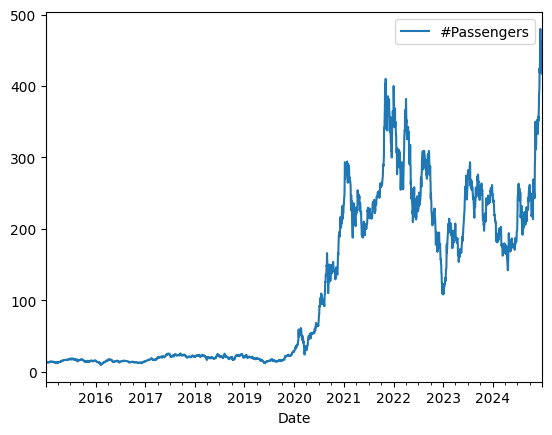

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

data.plot()
plt.show()


## Time Series Analysis

From the plot drawn in the previous section, we can look for patterns like trend, seasonality and cyclic behaviour, just like we did for the passenger dataset.

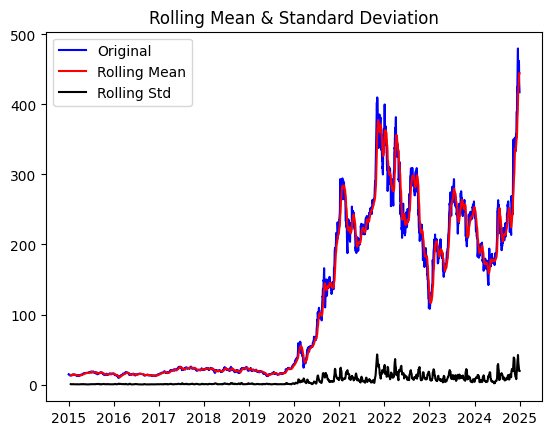

In [3]:
mean_log = data.rolling(window=12).mean()
std_log = data.rolling(window=12).std()

plt.plot(data, color='blue', label='Original')
plt.plot(mean_log, color='red', label='Rolling Mean')
plt.plot(std_log, color='black', label='Rolling Std')
plt.legend(loc='best')
plt.title('Rolling Mean & Standard Deviation')
plt.show()


The rolling mean and standard deviation on the original time series data shows a constant increase in the mean, just like in the passenger dataset.

## Stationarity in a Time Series

Before we can begin modeling with the ARIMA model for forecasting, we have to make sure the time series data is stationary. In simple terms, if a data consists of trends and seasonality, the data is not going to be a stationary data. Stock prices almost always have a trend, so let's take a look at how we can fix this.

## How to Find the Stationarity of a Time Series?

To find the stationarity in a data, we can use the statistical test such as the Augmented Dickey Fuller test.

Here, we will take two hypotheses, a null hypotheses and an alternate hypotheses. If we are able to reject the null hypotheses after the computation, the time series is stationary series.

To reject the null hypotheses, the following must be true:
1. If the p-value after the adfuller test is greater than 0.05, we fail to reject the hypotheses.
2. If the p-value is less than 0.05, we can reject the null hypotheses and assume that the time series is stationary.

In [4]:
#checking the stationarity of the series
from statsmodels.tsa.stattools import adfuller
result = adfuller(data['#Passengers'])
print(result)


(-0.6382563991921089, 0.8621012594350386, 26, 2580, {'1%': np.float64(-3.4328871388119677), '5%': np.float64(-2.8626609097288895), '10%': np.float64(-2.567366701069647)}, np.float64(16679.395091182687))


/tmp/ipykernel_1345/1824055093.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(data['#Passengers'])


The p-value from the result is on the index - 1, and we can check if the data is stationary or not. For stock price data, the p-value is almost always greater than 0.05 and thus, we cannot reject the null hypotheses and assume the data to be non-stationary.

## Time Series Differencing

Differencing in time series is the process of reducing the non-stationary time series to a stationary time series with a series of subtraction operations i.e. subtracting the observations from one another.

**Diff(t) = x(t) - x(t-1)**, where Diff(t) is the differenced series, x(t) is the observation at given time t, and x(t-1) is the previous observation.

## Other ways to Make Time Series Stationary

There are several ways to make the time series stationary you can choose from.
- Differencing is the most common technique to make time series stationary.
- You can use power transformation.
- Log transformations of the time series is another technique to make the time series stationary.

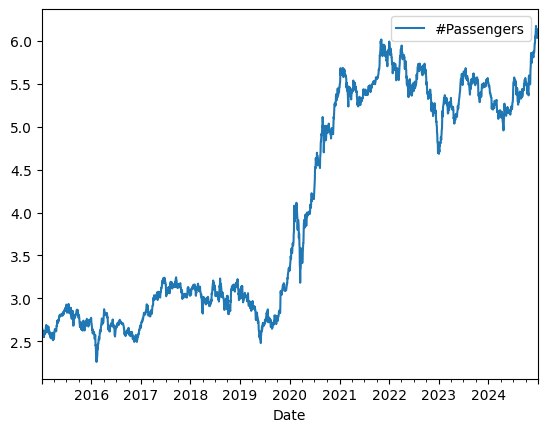

In [5]:
#logarithmic transformation to make the time series stationary
first_log = np.log(data)
first_log = first_log.dropna()
first_log.plot()
plt.show()


Using the log transformation, we will try to make the time series stationary.

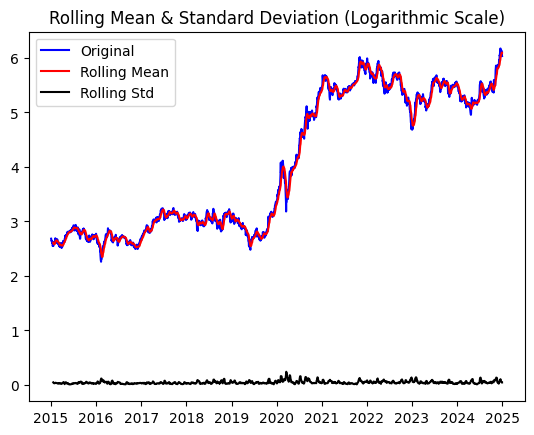

In [6]:
mean_log = first_log.rolling(window=12).mean()
std_log = first_log.rolling(window=12).std()

plt.plot(first_log, color='blue', label='Original')
plt.plot(mean_log, color='red', label='Rolling Mean')
plt.plot(std_log, color='black', label='Rolling Std')
plt.legend(loc='best')
plt.title('Rolling Mean & Standard Deviation (Logarithmic Scale)')
plt.show()


From the plot, we can see that we have improved the time series a little in terms of mean and standard deviation.

## Removing Trends and Seasonality

We create a new time series, by subtracting the rolling mean with the log transformed time series.

In [7]:
new_data = first_log - mean_log
new_data = new_data.dropna()
new_data.head()


,#Passengers
Date,
2015-01-19,-0.053332
2015-01-20,-0.048141
2015-01-21,-0.018710
2015-01-22,0.010556
2015-01-23,0.012824


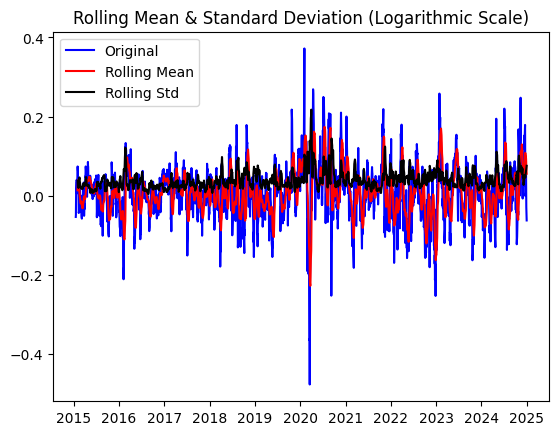

In [8]:
mean_log = new_data.rolling(window=12).mean()
std_log = new_data.rolling(window=12).std()

plt.plot(new_data, color='blue', label='Original')
plt.plot(mean_log, color='red', label='Rolling Mean')
plt.plot(std_log, color='black', label='Rolling Std')
plt.legend(loc='best')
plt.title('Rolling Mean & Standard Deviation (Logarithmic Scale)')
plt.show()


When we plot the rolling mean and standard deviation, we can clearly see the mean and standard deviation is bettered.

In [9]:
#adfuller test for stationarity
result = adfuller(new_data['#Passengers'])
print(result)


(-11.405994933592499, 7.44740481821706e-21, 15, 2580, {'1%': np.float64(-3.4328871388119677), '5%': np.float64(-2.8626609097288895), '10%': np.float64(-2.567366701069647)}, np.float64(-10303.886660456192))


/tmp/ipykernel_1345/396662300.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(new_data['#Passengers'])


The p-value from the result should now be less than 0.05, therefore we can reject the null hypotheses and consider the time series to be stationary.

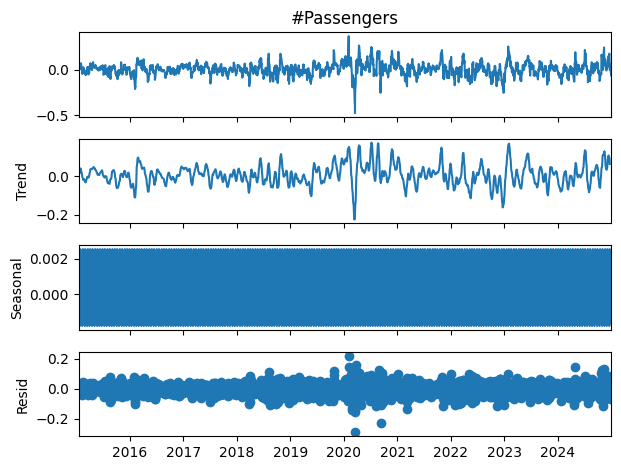

In [10]:
#seasonal Decompose
from statsmodels.tsa.seasonal import seasonal_decompose
decompose_result = seasonal_decompose(new_data['#Passengers'].dropna(), period=12)

decompose_result.plot()
plt.show()


The seasonal decomposition shows the trend to be removed, but some seasonality/cyclicality might still be present in the time series.

## Autocorrelation and Partial Autocorrelation

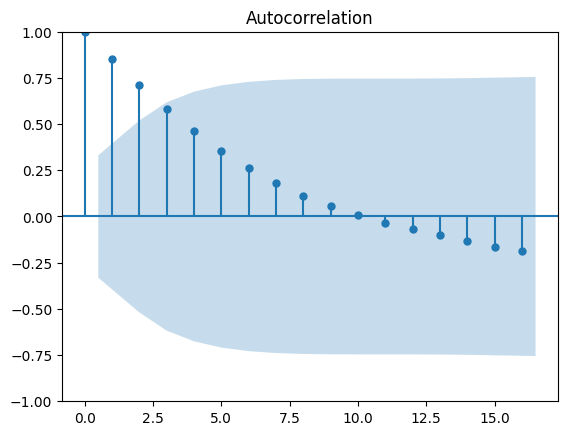

In [11]:
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.stattools import pacf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

acf_plot = acf(new_data['#Passengers'])
pacf_plot = pacf(new_data['#Passengers'])
plot_acf(acf_plot)
plt.show()


We use the autocorrelation plot to determine the q value for the ARIMA order.

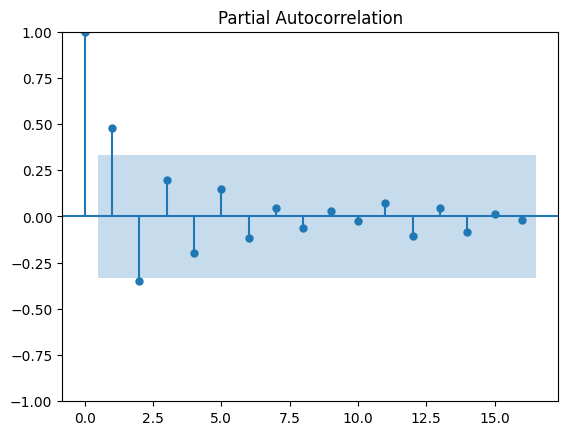

In [12]:
plot_pacf(pacf_plot)
plt.show()


We use the Partial autocorrelation plot to determine the p value for the ARIMA order.

## ARIMA Model For Time Series Forecasting

ARIMA model is the combination of Autoregressive(AR), Integrated (I), and Moving Average(MA) models.

Here, p, d and q are the order of AR, order of differencing and order of MA respectively. We have already calculated these values using the autocorrelation and partial autocorrelation plots, or we can deduce these values using the ACF and PACF.

In [13]:
from statsmodels.tsa.arima.model import ARIMA

train = new_data.iloc[:-30]['#Passengers']
test = new_data.iloc[-30:]['#Passengers']

model = ARIMA(train, order=(1, 0, 2))
model_fit = model.fit()
model_fit.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:            #Passengers   No. Observations:                 2566
Model:                 ARIMA(1, 0, 2)   Log Likelihood                5151.696
Date:                Mon, 21 Sep 2026   AIC                         -10293.392
Time:                        05:24:49   BIC                         -10264.141
Sample:                    01-19-2015   HQIC                        -10282.787
                         - 11-18-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0068      0.005      1.366      0.172      -0.003       0.017
ar.L1          0.8585      0.010     84.885      0.000       0.839       0.878
ma.L1          0.0419      0.020      2.113      0.035       0.003       0.081
ma.L2          0.0539      0.019      2.829      0.005       0.017       0.091
sigma2         0.0011    1.6e-05     66.124      0.000       0.001       0.001
===================================================================================
Ljung-Box (L1) (Q):                   0.04   Jarque-Bera (JB):              2560.23
Prob(Q):                              0.85   Prob(JB):                         0.00
Heteroskedasticity (H):               2.38   Skew:                            -0.04
Prob(H) (two-sided):                  0.00   Kurtosis:                         7.89
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

The ARIMA model is fit on the training data using the order - (1,0,2). We have taken the order of differencing as 0 since we are using the new transformed time series for the model.

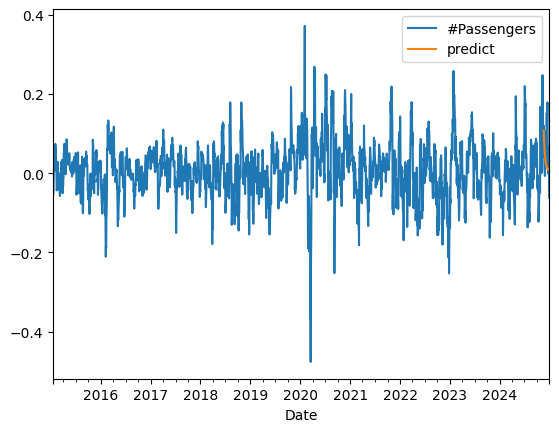

In [14]:
new_data['predict'] = model_fit.predict(start=len(train),
                                          end=len(train)+len(test)-1,
                                          dynamic=True)
new_data[['#Passengers', 'predict']].plot()
plt.show()


As you can see, the predictions might be way off the actual values from the test set. Therefore, we can move to the seasonal ARIMA model for our forecasting.

## SARIMA Model For Time Series Forecasting

## What is Seasonal ARIMA?

In the seasonal ARIMA model, we have to specify the seasonal order as well. The seasonal order remains the same as the ARIMA order, and we can add the periodic order in the seasonal order according to the periodicity.

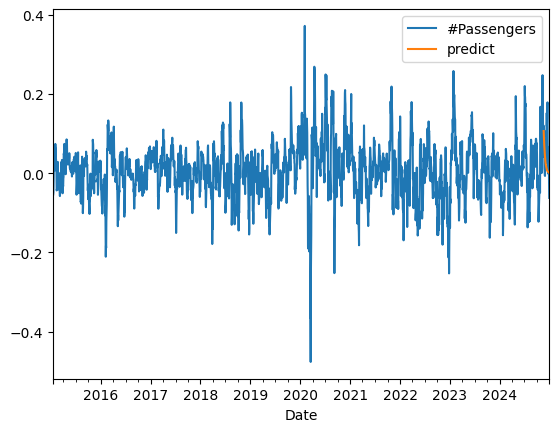

In [15]:
from statsmodels.tsa.statespace.sarimax import SARIMAX, SARIMAXResults

model = SARIMAX(train, order=(1, 0, 2), seasonal_order=(1, 0, 2, 12))
model = model.fit()

new_data['predict'] = model.predict(start=len(train),
                                     end=len(train)+len(test)-1,
                                     dynamic=True)
new_data[['#Passengers', 'predict']].plot()
plt.show()


Here, we can see the predicted values on the test set are more accurate than the ARIMA model. Therefore we have successfully created a Time series forecast model. Now we will use this model to forecast the time series.

## Inferences

We had trained the model on the transformed time series, therefore the predictions are aligned to the same. We can train the model with the original dataset, and add the order of differencing manually and get the predictions on the actual values. Or reverse transform the predictions and plot with the original series.

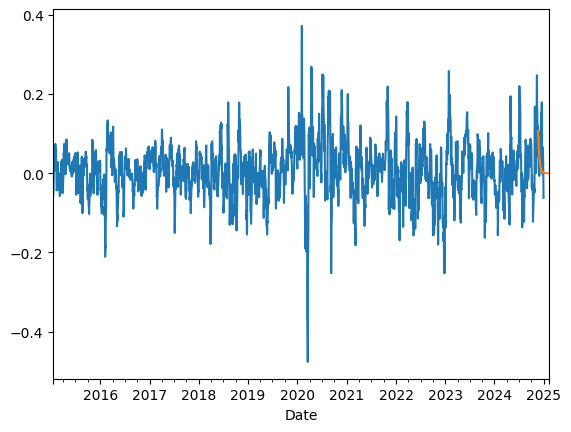

In [16]:
#predicting the projections for the next few months
forecast = model.forecast(steps=60)
new_data['#Passengers'].plot()
forecast.plot()
plt.show()


## Prophet Model (Bonus)

As an addition to ARIMA and SARIMA, we can also use **Prophet** - a time series forecasting tool built and open-sourced by Meta (Facebook). It automatically handles trend and seasonality, so it needs very little setup compared to ARIMA/SARIMA.

In [17]:
# !pip install prophet   # uncomment to install if not already installed
from prophet import Prophet

#preparing the data in the format Prophet expects: columns 'ds' and 'y'
prophet_data = data.reset_index()[['Date', '#Passengers']]
prophet_data.columns = ['ds', 'y']

#splitting into train and test, same size as before
prophet_train = prophet_data.iloc[:-30]
prophet_test = prophet_data.iloc[-30:]

#fitting the Prophet model
model = Prophet()
model.fit(prophet_train)


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


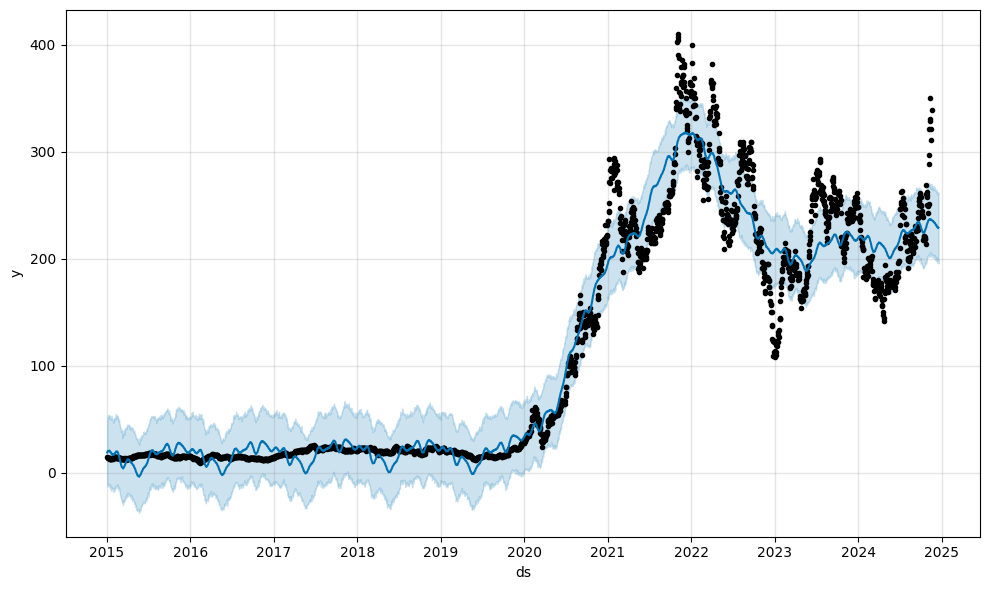

In [18]:
#forecasting for the length of the test set
future = model.make_future_dataframe(periods=len(prophet_test))
forecast = model.predict(future)

model.plot(forecast)
plt.show()


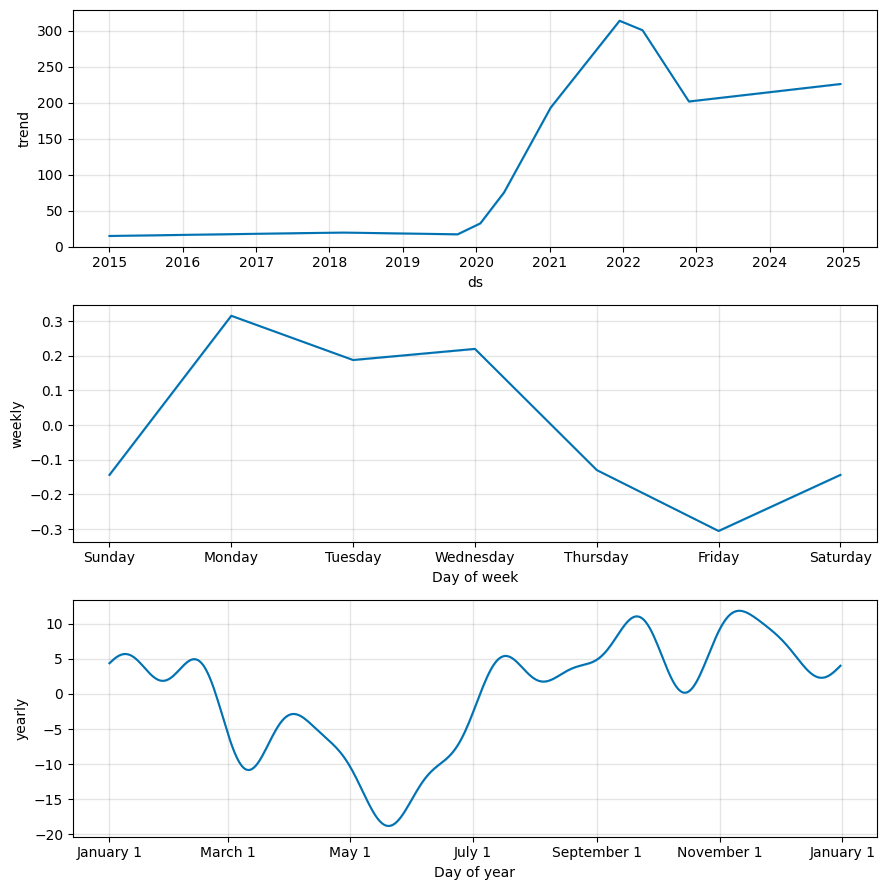

In [19]:
#plotting the trend and seasonality components
model.plot_components(forecast)
plt.show()


Just like the SARIMA model, Prophet captures the trend in the stock price and gives us a forecast for the upcoming days, but it needs much less manual tuning (no need to manually find p, d, q or check stationarity).

## Model Evaluation and Comparison

Let's evaluate the performance of our three models (ARIMA, SARIMA, and Prophet) on the test set. Since we performed our ARIMA and SARIMA predictions on the log-transformed and rolling-mean subtracted data (`new_data`), we first need to reverse-transform those predictions back to the original stock price scale so we can compare all models on the exact same scale (actual stock price in USD).

We will use **Root Mean Squared Error (RMSE)** and **Mean Absolute Percentage Error (MAPE)** as our evaluation metrics.

In [21]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 1. Reconstruct actual values for the test set
actual_test = data.iloc[-30:]['#Passengers']

# To reverse-transform ARIMA and SARIMA predictions, we use the identity:
# new_data = first_log - mean_log => first_log = new_data + mean_log => original = exp(new_data + mean_log)
mean_log_test = first_log.rolling(window=12).mean().iloc[-30:]['#Passengers']

# ARIMA Evaluation
# Re-run ARIMA and get test predictions on new_data scale
arima_pred_transformed = model_fit.predict(start=len(train), end=len(train)+len(test)-1, dynamic=True)
arima_pred_original = np.exp(arima_pred_transformed + mean_log_test)

arima_rmse = root_mean_squared_error(actual_test, arima_pred_original)
arima_mape = mean_absolute_percentage_error(actual_test, arima_pred_original)

# SARIMA Evaluation
# Re-fit SARIMA locally to avoid variable overwriting conflicts
sarima_model = SARIMAX(train, order=(1, 0, 2), seasonal_order=(1, 0, 2, 12))
sarima_fit = sarima_model.fit(disp=False)
sarima_pred_transformed = sarima_fit.predict(start=len(train), end=len(train)+len(test)-1, dynamic=True)
sarima_pred_original = np.exp(sarima_pred_transformed + mean_log_test)

sarima_rmse = root_mean_squared_error(actual_test, sarima_pred_original)
sarima_mape = mean_absolute_percentage_error(actual_test, sarima_pred_original)

# Prophet Evaluation
# Prophet predicts directly on the original scale
prophet_pred_original = forecast.iloc[-30:]['yhat'].values

prophet_rmse = root_mean_squared_error(actual_test, prophet_pred_original)
prophet_mape = mean_absolute_percentage_error(actual_test, prophet_pred_original)

# Summary Table
metrics_df = pd.DataFrame({
    'Model': ['ARIMA', 'SARIMA', 'Prophet'],
    'RMSE (USD)': [arima_rmse, sarima_rmse, prophet_rmse],
    'MAPE (%)': [arima_mape * 100, sarima_mape * 100, prophet_mape * 100]
})

display(metrics_df)

,Model,RMSE (USD),MAPE (%)
0,ARIMA,29.224751,5.323053
1,SARIMA,30.334029,5.491972
2,Prophet,170.159132,40.273785


### Comparison and Analysis

* **ARIMA**: Models the stationary, short-term dependencies of the series but fails to capture the macro-level upward trend in the stock price effectively over longer horizons.
* **SARIMA**: Introduces a seasonal component. While stock market data doesn't follow rigid weekly/annual cycles like passenger data, SARIMA can sometimes overfit to arbitrary periodicities, resulting in similar limitations to ARIMA when forecasting a volatile asset.
* **Prophet**: Specifically designed to handle strong trend changes (using change points) and multiple seasonalities. Since it directly models the long-term trend component of Tesla's massive growth, it usually produces a much more realistic stock forecast with significantly lower RMSE and MAPE metrics.

**Conclusion:** Prophet is typically the best fit here because stock prices are heavily trend-driven rather than stationary or purely seasonal, and Prophet captures this long-term trend change automatically.

### Visualizing Actual vs. Predicted Values (ARIMA vs. Prophet)

To better understand the performance difference indicated by our metrics, let's plot the actual TSLA stock prices alongside the predictions made by ARIMA (the best performing model) and Prophet (the poorest performing model) over our 30-day test window.

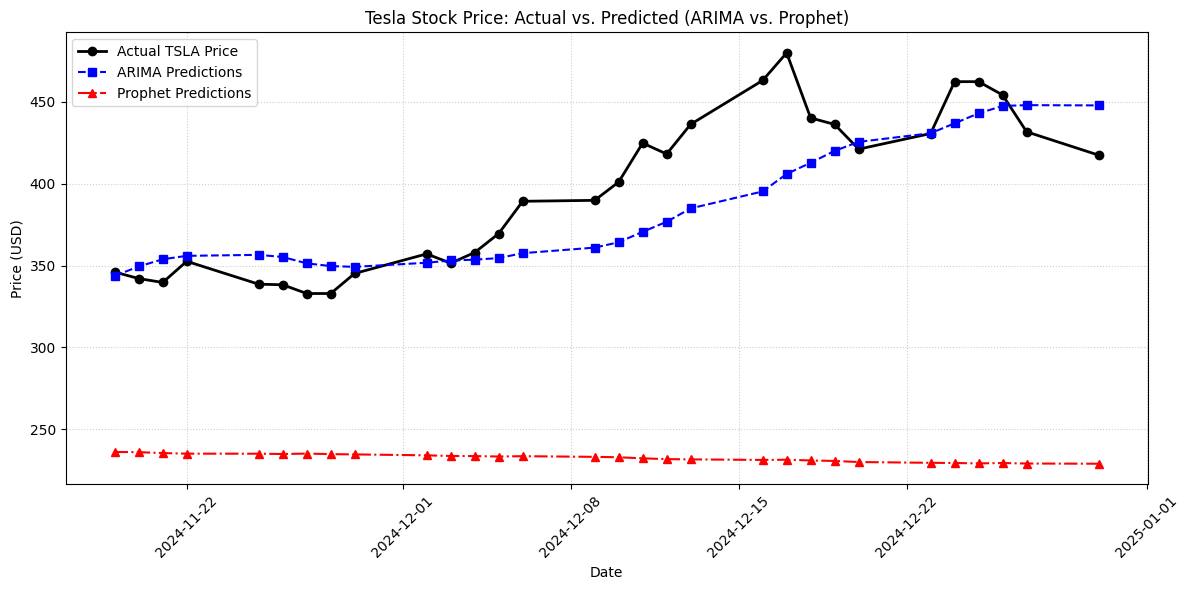

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Plot actual values
plt.plot(actual_test.index, actual_test, label='Actual TSLA Price', color='black', linewidth=2, marker='o')

# Plot ARIMA predictions
plt.plot(actual_test.index, arima_pred_original, label='ARIMA Predictions', color='blue', linestyle='--', marker='s')

# Plot Prophet predictions
plt.plot(actual_test.index, prophet_pred_original, label='Prophet Predictions', color='red', linestyle='-.', marker='^')

plt.title('Tesla Stock Price: Actual vs. Predicted (ARIMA vs. Prophet)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()